# Site Selection: Restaurant clusters

>* 👟 Ready To Run!
* 🖥️ Requires ArcPy
* 🖥️ Requires GeoEnrichment Organization Configuration
* 🔬 Data Science
* 🚀 Data Exploration and Cleaning
* 📈 Graphing and Visualization


## An Example of Spatial Analysis in ArcGIS Using Density-based Clustering 

Prospecting a successful retail location often requires a thorough understanding of where people shop, dine, and linger for entertainment in a study area. One useful way to start making sense of the vast quantities of retail business information and start finding the locations that matter is to use spatial clustering to find locations with a dense retail presence. 

This example starts with retail business data in Pittsburgh, Pennsylvania, USA, and leverages a couple of Spatial Statistics tools in ArcGIS ([Density-based Clustering](http://pro.arcgis.com/en/pro-app/tool-reference/spatial-statistics/densitybasedclustering.htm), [Directional Distribution (Standard Deviational Ellipse)](http://pro.arcgis.com/en/pro-app/tool-reference/spatial-statistics/directional-distribution.htm)) to incorporate the dense retail data into defined cluster locations. These locations can then be further analyzed to aid decision making for your organization. 

## Steps

This is a basic example that will cover the following steps:

1) Retrieve Pittsburgh restaurant data.


2) Explore the data through tables, charts, and maps.


3) Perform spatial analysis:

    Finding Restaurant Zones through Clustering

    - Density-based Clustering
    - Directional Distribution (Standard Deviational Ellipse)

    Prioritizing Restaurant Zones
    
    - Aggregated Sales Volume per Ellipse Zone
    - Density of Hot Spot Restaurants in the Ellipse Zone

4) Present the results.

## General Workflow

### Preliminary Setup

Import the needed modules, including ArcPy, the ArcGIS API for Python, and other useful modules. Then, connect to our `GIS`.

In [1]:
import os
import time
import tempfile

import numpy as np
import pandas as pd

import arcgis
from arcgis import features
from arcgis.features import GeoAccessor, GeoSeriesAccessor
from arcgis.geoenrichment import *
from arcgis.geometry import project

gis = arcgis.gis.GIS("https://pythonapi.playground.esri.com/portal",
                     "arcgis_python", "amazing_arcgis_123", verify_cert=False)

Now, let's define our `/arcgis/home/` location and create some helper functions to be used later.

In [2]:
home_dir = tempfile.gettempdir()

In [3]:
# Create a helper function that receives a spatially-enabled dataframe 
# and column as input, and returns a map widget, symbolized layer, and 
# bokeh histogram using the layer's colormap
def create_map_and_histogram(map_location, sdf, column, 
                             method='esriClassifyNaturalBreaks', 
                             class_count=5, cmap='OrRd', 
                             alpha=0.8, plot_height=600, plot_width=600):
    """
    create_map_and_histogram
    inputs:
        map_location: Location for the map widget. The entry 
        will be geocoded and used as the starting extent for the 
        map widget. Example: "Pittsburgh"

        sdf: spatially-enabled dataframe that is plotted on a map and 
        histogram

        column: column to use for layer symbology and histogram
    return: map widget, bokeh plot
    """
    
    # Create map
    map_obj = gis.map(map_location)
    sdf.spatial.plot(map_widget=map_obj, renderer_type='c', 
                     method=method, class_count=class_count, 
                     col=column, cmap=cmap, alpha=0.8)  
    
    # Extract the layer's class breaks and colors
    class_breaks = map_obj.layers[0].layer\
                      .layerDefinition.drawingInfo.renderer\
                      .classBreakInfos
    cbs_list = []
    cmap_list = []
    for cb in class_breaks:
        cbs_list.append(cb.classMaxValue)
        cmap_list.append('#%02x%02x%02x' % (cb.symbol.color[0], 
                                            cb.symbol.color[1], 
                                            cb.symbol.color[2]))
    
    # Create a histogram of salesvol values
    hist, edges = np.histogram(sdf[column],
                              bins=class_count)

    # Put the information in a dataframe
    hist_df = pd.DataFrame({column: hist,
                            'left': edges[:-1],
                            'right': edges[1:]})
    
    # Add colors to each hist_df record
    hist_df['color'] = pd.Series(cmap_list)

    # Create the blank plot
    p = None

    # Return outputs
    return map_obj, p

In [4]:
# Helper functions to change the extent of a web map 
# based on ellipse centroids
def return_center_dict(centerx, centery):
    center_shape_dict = {}
    center_shape_dict['spatialReference'] = \
        {'latestWkid': 3857, 'wkid': 102100}
    center_shape_dict['x'] = centerx
    center_shape_dict['y'] = centery
    return center_shape_dict

def visit_sites(m, points, timesleep, zoom_level=15):
    m.zoom = zoom_level
    i = 0
    for i in range(len(points)):
        m.center = [points[i]['y'], points[i]['x']]
        time.sleep(timesleep)
        
def visit_ellipse_features_on_map_widget(map_obj, sdf, zoom_level=15, 
                                         number_of_records=None, 
                                         timesleep=5):
    # Create a center_xy column from the sdf
    sdf['center_xy'] = sdf.apply(
        lambda x: return_center_dict(x['centerx'], x['centery']), axis=1)
    if number_of_records:
        sitelist = sdf.head(number_of_records)['center_xy'].tolist()
    else:
        sitelist = sdf.head()['center_xy'].tolist()
    xys = project(sitelist, in_sr=3857, out_sr=4326)
    visit_sites(map_obj, xys, timesleep)        

# <span style="color:purple">1) Retrieve Pittsburgh restaurant data</span>

We published an item containing Pittsburgh restaurants to the ArcGIS Enterprise. Let's find this item using the "Add" toolbar and load it into our notebook as an item variable.

<Item title:"restaurants_pittsburgh" type:Feature Layer Collection owner:api_data_owner>
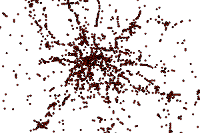

In [5]:
restaurants_item = gis.content.search(f'restaurants_pittsburgh',
                                      item_type = "Feature Service",
                                      outside_org=True)[0]
restaurants_item

The [spatially-enabled dataframe](https://developers.arcgis.com/python/guide/introduction-to-the-spatially-enabled-dataframe/) helps us explore the data in a tabular format by leveraging the Pandas library.

In [6]:
restaurants_sdf = pd.DataFrame.spatial.from_layer(
    restaurants_item.layers[0])
restaurants_sdf.head()

,SHAPE,city,coname,db_nqiuz_h,empnum,fid,frncod,hdbrch,iscode,loc_name,...,score,sic,source,sqftcode,state,state_name,status,street,zip,zip4
0,"{""x"": -8919964.0056, ""y"": 4867758.91170001, ""s...",MARIANNA,RUDNICK'S,1,6.0,1,,,3,StreetAddress,...,100.0000,581208,INFOGROUP,A,PA,Pennsylvania,M,TEN MILE RD,15345,1080
1,"{""x"": -8905258.700799996, ""y"": 4865826.0264, ""...",FREDERICKTOWN,RIVERSIDE INN,2,5.0,2,,,,StreetAddress,...,90.0938,581208,INFOGROUP,A,PA,Pennsylvania,M,FRONT ST,15333,
2,"{""x"": -8905314.360600002, ""y"": 4866727.0238000...",FREDERICKTOWN,RIVIERA RESTAURANT LOUNGE,3,5.0,3,,,,StreetAddress,...,100.0000,581208,INFOGROUP,A,PA,Pennsylvania,M,FRONT ST,15333,
3,"{""x"": -8904590.783899996, ""y"": 4868224.0231000...",BETHLEHEM,KUKI CHINESE RESTAURANT,4,3.0,4,,,C,PointAddress,...,86.8281,581208,INFOGROUP,A,PA,Pennsylvania,M,E 3RD ST,18015,1306
4,"{""x"": -8896241.822099997, ""y"": 4844052.5718000...",MASONTOWN,DOLFI'S,5,10.0,5,,,,StreetAddress,...,100.0000,581208,INFOGROUP,B,PA,Pennsylvania,M,RIVER AVE,15461,1551


We're also going to temporarily store this spatially-enabled dataframe as a feature class in order to run ArcPy operations on the data.

# <span style="color:purple">2) Explore the data through tables, charts, and maps.</span>

In [7]:
# Get the amount of records and columns in our data
print("Amount of restaurants: {0}\nAmount of attributes: {1}".format(
          restaurants_sdf.shape[0], restaurants_sdf.shape[1]))

Amount of restaurants: 5026
Amount of attributes: 23


In [8]:
# Get summary statistics on numeric fields
restaurants_sdf.describe()

,db_nqiuz_h,empnum,fid,salesvol,score
count,5026.000000,5026.000000,5026.000000,5026.000000,5026.000000
mean,2513.500000,17.216076,2513.500000,802.645444,99.608847
std,1451.025557,24.190230,1451.025557,1130.667265,1.855258
min,1.000000,1.000000,1.000000,0.000000,85.703100
25%,1257.250000,6.000000,1257.250000,280.000000,100.000000
50%,2513.500000,8.000000,2513.500000,374.000000,100.000000
75%,3769.750000,19.000000,3769.750000,888.000000,100.000000
max,5026.000000,300.000000,5026.000000,14035.000000,100.000000


In [9]:
# Get a basic map of the restaurant locations as points
restaurants_map = gis.map("Pittsburgh")
restaurants_sdf.spatial.plot(map_widget=restaurants_map)
restaurants_map

MapView(layout=Layout(height='400px', width='100%'))

In [10]:
# Use our helper function to show a map and histogram 
# of restaurants symbolized by sales volume 
restaurants_map, sales_hist = create_map_and_histogram("Pittsburgh", 
                                  restaurants_sdf, "salesvol")
restaurants_map

MapView(layout=Layout(height='400px', width='100%'))

See https://mybinder.org/v2/gh/bokeh/bokeh-notebooks/master?filepath=tutorial%2F00%20-%20Introduction%20and%20Setup.ipynb for a guide to Bokeh's plotting capabilities

## What are the top five restaurants by sales volume?

In [11]:
# Get the restaurants with the highest sales revenue by 
# sorting on the 'SALESVOL' column
top_sales_sdf = restaurants_sdf.sort_values(
    by=['salesvol'], 
    ascending=False).reset_index()
top_five_sdf = top_sales_sdf.head()

print("Top 5 Restaurants in Pittsburgh by Sales Volume: ")
top_five_sdf[['coname', 'salesvol', 'street', 'city', 'state', 
              'state_name', 'zip']]

Top 5 Restaurants in Pittsburgh by Sales Volume: 


,coname,salesvol,street,city,state,state_name,zip
0,CHEESECAKE FACTORY,14035.0,ROSS PARK MALL DR,PITTSBURGH,PA,Pennsylvania,15237
1,EAT'N PARK,12865.0,PARK MANOR DR,PITTSBURGH,PA,Pennsylvania,15205
2,CHEESECAKE FACTORY,12631.0,S 27TH ST,PITTSBURGH,PA,Pennsylvania,15203
3,M I FRIDAY,11695.0,PERRY HWY,PITTSBURGH,PA,Pennsylvania,15229
4,NANA,11695.0,WATERFRONT DR,PITTSBURGH,PA,Pennsylvania,15222


In [12]:
# Plot the highest five selling restaurants
top_five_restaurants_map = gis.map("Pittsburgh")
top_five_sdf.spatial.plot(map_widget=top_five_restaurants_map)
top_five_restaurants_map

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-dev\lib\site-packages\pandas\core\generic.py:6244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)


MapView(layout=Layout(height='400px', width='100%'))

## What are the top five zip codes by sales volume?

In [13]:
# Determine the top five zip codes by average restaurant sales volume

# Use groupby object to make calculations by Zip Code
zip_groupby = restaurants_sdf.groupby(restaurants_sdf['zip'])
# Determine means for numeric columns by zip
zip_mean_sales_df = zip_groupby.mean().sort_values(by=['salesvol'], 
                                                   ascending=False)
# Calculate Zip ranks by average sales volume
zip_mean_sales_df['Zip Ave. Sales Rank'] = \
    zip_mean_sales_df['salesvol'].rank(ascending=False)

# Drop the unneeded 'SCORE' field
del zip_mean_sales_df['score']

zip_mean_sales_df.head()

,db_nqiuz_h,empnum,fid,salesvol,Zip Ave. Sales Rank
zip,,,,,
15231,4293.818182,39.818182,4293.818182,1862.272727,1.0
15275,3861.695652,38.521739,3861.695652,1801.652174,2.0
15482,950.000000,35.000000,950.000000,1637.000000,3.0
15084,1093.789474,32.605263,1093.789474,1524.842105,4.0
15205,3716.203540,30.424779,3716.203540,1422.796460,5.0


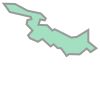

In [14]:
# Load the geoenrichment module's country object for the US, 
# and pre-cache some geometry
usa = Country.get("United States")
usa.subgeographies.states['Pennsylvania'].zip5['15275'].geometry

In [15]:
# Create a basic map showing the top five zip codes
top_five_zip_map = gis.map("Pittsburgh")
for zip5 in zip_mean_sales_df.head().index.values.tolist():
    top_five_zip_map.draw(usa.subgeographies.states['Pennsylvania']\
                              .zip5[str(zip5)].geometry)
restaurants_sdf.spatial.plot(map_widget=top_five_zip_map, alpha=0.1, 
                             cmap='Greys', outline_color='Greys')
top_five_zip_map 

MapView(layout=Layout(height='400px', width='100%'))

# <span style="color:purple">3) Perform spatial analysis</span> 

To help us identify potential sites for further analysis, we will leverage spatial clustering to find locations with dense retail presence. In this case, Density-based Clustering and Directional Distribution are very useful to help us identify these potential sites. 

## Density-based Clustering

![clustering](https://github.com/Qberto/arcgispythonapi_arcpy-spatial_statistics_examples/raw/5f8994ab80301d8ae145e9081b16c1389a5729d0/img/dbclustering_01.png "Density-based Clustering")

The [Density-based Clustering tool](http://pro.arcgis.com/en/pro-app/tool-reference/spatial-statistics/how-density-based-clustering-works.htm) works by detecting areas where points are concentrated and where they are separated by areas that are empty or sparse. Points that are not part of a cluster are labeled as noise.

This tool uses unsupervised machine learning clustering algorithms which automatically detect patterns based purely on spatial location and the distance to a specified number of neighbors. These algorithms are considered unsupervised because they do not require any training on what it means to be a cluster.

#### Three clustering algorithms:

The Density-based Clustering tool provides three different Clustering Methods with which to find clusters in your point data:

- _Defined distance (DBSCAN)_ — Uses a specified distance to separate dense clusters from sparser noise. The DBSCAN algorithm is the fastest of the clustering methods, but is only appropriate if there is a very clear Search Distance to use, and that works well for all potential clusters. This requires that all meaningful clusters have similar densities.

- _Self-adjusting (HDBSCAN)_ — Uses a range of distances to separate clusters of varying densities from sparser noise. The HDBSCAN algorithm is the most data-driven of the clustering methods, and thus requires the least user input.

- _Multi-scale (OPTICS)_ — Uses the distance between neighboring features to create a reachability plot which is then used to separate clusters of varying densities from noise. The OPTICS algorithm offers the most flexibility in fine-tuning the clusters that are detected, though it is computationally intensive, particularly with a large Search Distance.

#### Where are the ellipse zones with the highest total restaurant sales volumes?

#### Where are the ellipse zones with the highest average restaurant sales volumes?

Let's view some of the ellipse zones with the highest average restaurant sales volume by using a helper function (defined above in the 'setup' section).

In [16]:
# Run optimized hot spots, using sales volume as the analysis field
from uuid import uuid4

output_name = str(uuid4()).replace("-","")

restaurant_hot_spots_item = features.analyze_patterns.find_hot_spots(
    restaurants_item, analysis_field='salesvol', 
    output_name=output_name, gis=gis)

In [17]:
restaurant_hot_spots_item

<Item title:"f4853c14dabf46b0a3d366f4a271f80b" type:Feature Layer Collection owner:arcgis_python>

In [18]:
# Create a map of Pittsburgh to show hot spot outputs
hot_spots_map = gis.map("Pittsburgh")
hot_spots_map.add_layer(restaurant_hot_spots_item)
hot_spots_map.zoom = 10
hot_spots_map

MapView(layout=Layout(height='400px', width='100%'))

Now let's bring back our spatially-enabled dataframe from our previous step to summarize the statistics of the hot spot analysis for restaurants within each ellipse zone.

<Item title:"Ellipse_From_Restaurant" type:Feature Layer Collection owner:api_data_owner>
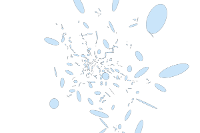

In [19]:
ellipses_item = gis.content.search('"Ellipse_From_Restaurant" owner:api_data_owner',
                                    item_type="Feature Layer")[0]
ellipses_item

In [20]:
from arcgis.features import summarize_data

# Calculate the sum of sales volume and the mean of sales volume
sum_fields = []

output_name2 = str(uuid4()).replace("-", "")

sv_summary = summarize_data.aggregate_points(
    point_layer = restaurants_item.layers[0],
    polygon_layer = ellipses_item.layers[0],
    summary_fields=sum_fields,
    output_name=output_name2)


output_name3 = str(uuid4()).replace("-", "")

# Run the calculation
sv_summary2 = summarize_data.aggregate_points(
    point_layer = restaurant_hot_spots_item.layers[0],
    polygon_layer = sv_summary.layers[0],
    summary_fields=sum_fields,
    output_name=output_name3)
sv_summary2

<Item title:"94fc793461f9419e9d9c236071d2b2d6" type:Feature Layer Collection owner:arcgis_python>

We can now make a map of the ellipse zones symbolized by the average gi bin, which represents the designation of hot spots, cold spots, or unsignificant spots. 

Finally, let's convert our summary output for ellipse zones into a spatially-enabled dataframe, so we can make our final priority assessment.

In [21]:
# Convert the output item into a spatially-enabled dataframe
fset = sv_summary2.layers[0].query()
summary2_sdf = fset.sdf
summary2_sdf.head()

,objectid_1,point_count_1,point_count,objectid,centerx,centery,xstddist,ystddist,rotation,cluster_id,st_area_sh,st_length_,analysisarea,SHAPE
0,1,18,18,1,-8.910530e+06,5.023269e+06,2151.586100,12525.834221,22.711797,1,8.466291e+07,52077.080229,18.559872,"{""rings"": [[[-8908544.9296, 5022437.849299997]..."
1,2,6,6,4,-8.847666e+06,4.849466e+06,3419.763571,13281.725110,19.417593,4,1.426850e+08,57151.974219,32.397132,"{""rings"": [[[-8844440.4574, 4848328.960000001]..."
2,3,11,11,5,-8.875420e+06,5.007396e+06,3412.772598,12791.984258,14.330382,5,1.371428e+08,55269.602930,30.162179,"{""rings"": [[[-8872113.4345, 5006551.2619], [-8..."
3,4,13,13,2,-8.825619e+06,4.985812e+06,11059.807891,19222.922180,23.821812,2,6.678744e+08,96871.018626,147.534659,"{""rings"": [[[-8815501.4462, 4981344.867600001]..."
4,5,6,6,7,-8.894437e+06,4.828135e+06,216.891213,602.999791,24.840462,7,4.108535e+05,2720.636928,0.093683,"{""rings"": [[[-8894239.7663, 4828043.785599999]..."


### Calculating Priority Scores

We are now ready to assign a priority score for each ellipse zone based on basic restaurant sales volume statistics at each ellipse, as well as the presence of hot spot and cold spot restaurant features within each zone. 

In order to help make this analysis flexible for further refinements, let's apply a weight to each of these factors. 

Factors:

- Amount of restaurants in zone: 0.75
- Average sales volume in zone: 1.0
- Average GI Bin score in zone: 2.0

The final priority score will be assessed as the normalized addition of each factor multiplied by its weight. The formula therefore is as follows:

P = 

In [22]:
# Establish weight values for each factor
priority_score_weights = {
    "restaurant count":0.75,
    "mean sales volume":1.0,
    "mean gi bin score": 2.0
}

In [23]:
# Establish a list of fields to compute z-scores for
list_of_fields_to_normalize = [
    'point_count',
    'mean_salesvol',
    'mean_gi_bin'
]

In [24]:
summary2_sdf.head()

,objectid_1,point_count_1,point_count,objectid,centerx,centery,xstddist,ystddist,rotation,cluster_id,st_area_sh,st_length_,analysisarea,SHAPE
0,1,18,18,1,-8.910530e+06,5.023269e+06,2151.586100,12525.834221,22.711797,1,8.466291e+07,52077.080229,18.559872,"{""rings"": [[[-8908544.9296, 5022437.849299997]..."
1,2,6,6,4,-8.847666e+06,4.849466e+06,3419.763571,13281.725110,19.417593,4,1.426850e+08,57151.974219,32.397132,"{""rings"": [[[-8844440.4574, 4848328.960000001]..."
2,3,11,11,5,-8.875420e+06,5.007396e+06,3412.772598,12791.984258,14.330382,5,1.371428e+08,55269.602930,30.162179,"{""rings"": [[[-8872113.4345, 5006551.2619], [-8..."
3,4,13,13,2,-8.825619e+06,4.985812e+06,11059.807891,19222.922180,23.821812,2,6.678744e+08,96871.018626,147.534659,"{""rings"": [[[-8815501.4462, 4981344.867600001]..."
4,5,6,6,7,-8.894437e+06,4.828135e+06,216.891213,602.999791,24.840462,7,4.108535e+05,2720.636928,0.093683,"{""rings"": [[[-8894239.7663, 4828043.785599999]..."


In [25]:
# Define a helper function to calculate the Priority Score
def calculate_priority_score(point_count, mean_salesvol, mean_gi_bin):
    score_val = \
        float((float(point_count) * \
                  priority_score_weights['restaurant count']) + \
              (float(mean_salesvol) * \
                  priority_score_weights['mean sales volume']) + \
              (float(mean_gi_bin) * \
                  priority_score_weights['mean gi bin score']))
    return score_val